In [ ]:
# ==========================================================
# SECTION 1 - DATA COLLECTION FROM ChEMBL (OPTIONAL)
# ==========================================================
#
# This section reproduces the data collection directly from
# ChEMBL.
#
# Because the ChEMBL database is continuously updated,
# the number of retrieved compounds may differ from the
# dataset used in this work.
#
# The curated dataset employed in this study is already
# available in:
#
# data/tcruzi_bioactivity_dataset.csv
#
# Therefore, this section can be skipped.
# ==========================================================

!pip install chembl_webresource_client rdkit scikit-learn pandas numpy matplotlib seaborn umap-learn -q

from chembl_webresource_client.new_client import new_client
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator


sns.set_theme(style="ticks")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11


# Data collection – ChEMBL API
chembl = new_client

# Target search - Trypanosoma cruzi
targets = chembl.target.search('Trypanosoma cruzi')
target    = targets[0]
target_id = target['target_chembl_id']
print(f"Selected target: {target_id}")

# Activity filtering
activities = chembl.activity.filter(
    target_chembl_id=target_id,
    standard_type="IC50",
    standard_relation="=",
    canonical_smiles__isnull=False
)

df = pd.DataFrame(list(activities[:1800]))


# Dataset curation

# Removal of entries with no activity value
df = df[df.standard_value.notna()]

# Exclusion of enzyme assays
if 'assay_type' in df.columns:
    df = df[df.assay_type != 'E']

# Exclusion of cytotoxicity assays
if 'assay_description' in df.columns:
    df = df[~df.assay_description.str.contains(
        'cytotoxicity|cytotoxic|cell viability',
        case=False,
        na=False
    )]


if 'standard_flag' in df.columns:
    df['standard_flag'] = df['standard_flag'].astype(str)
    df = df[~df['standard_flag'].str.contains('Suspicious', case=False, na=False)]


if 'data_validity_comment' in df.columns:
    df = df[
        df['data_validity_comment'].isna() |
        df['data_validity_comment'].str.contains('valid', case=False, na=True)
    ]


df['standard_value'] = pd.to_numeric(df['standard_value'], errors='coerce')
df = df[df['standard_value'].notna()]

# Removal of duplicates by SMILES
df.drop_duplicates(subset=['canonical_smiles'], inplace=True)

# IC50 (nM) → pIC50
df['pIC50'] = -np.log10(df['standard_value'] * 1e-9)
df = df[np.isfinite(df['pIC50'])]

# Generation of ECFP4 fingerprints (Morgan, radius=2, 2048 bits)
def smiles_to_ecfp4(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    fp = morgan_gen.GetFingerprint(mol)
    return np.array(fp)

df['ecfp4'] = df['canonical_smiles'].apply(smiles_to_ecfp4)
df = df[df['ecfp4'].notna()]

df[['molecule_chembl_id', 'canonical_smiles', 'pIC50']].to_csv(
    'tcruzi_bioactivity_dataset.csv', index=False
)


ecfp4_matrix = np.vstack(df['ecfp4'].values)
np.save('t_cruzi_ecfp4_fingerprints.npy', ecfp4_matrix)


print(f"tcruzi_bioactivity_dataset.csv  — {len(df)} compounds")

Training: 1048 compounds | Test: 186 compounds

Model                  | R² Training | RMSE     
--------------------------------------------------------------
Random Forest          | 0.750      | 0.653    
Support Vector         | 0.732      | 0.676    
Gradient Boosting      | 0.681      | 0.738    
K-Neighbors (KNN)      | 0.732      | 0.676    

 KNN model:
  R²   = 0.522 ± 0.126
  RMSE = 0.899 ± 0.056

External Validation — pIC50 EXPERIMENTAL vs KNN
Compound  pIC50 Exp.  pIC50 KNN
  LCF548        4.44       4.15
  LCF553        4.55       4.14
 LCFD511        5.12       5.06
 LCFD509        4.95       4.57
 LCFD501        4.55       4.42
 LCFD528        5.09       5.04
 LCFD516        4.90       3.62
 LCFD523        4.62       5.17
 LCFD541        4.74       4.03


 Model Predictions 
Model     Gradient Boosting  K-Neighbors (KNN)  Random Forest  Support Vector
Compound                                                                     
LCF548                 5.98               

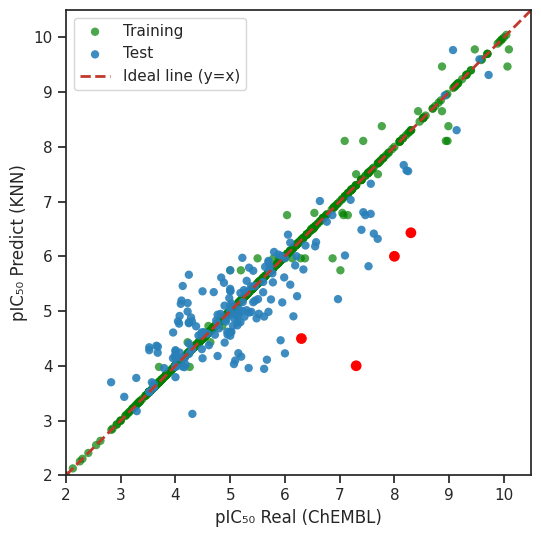

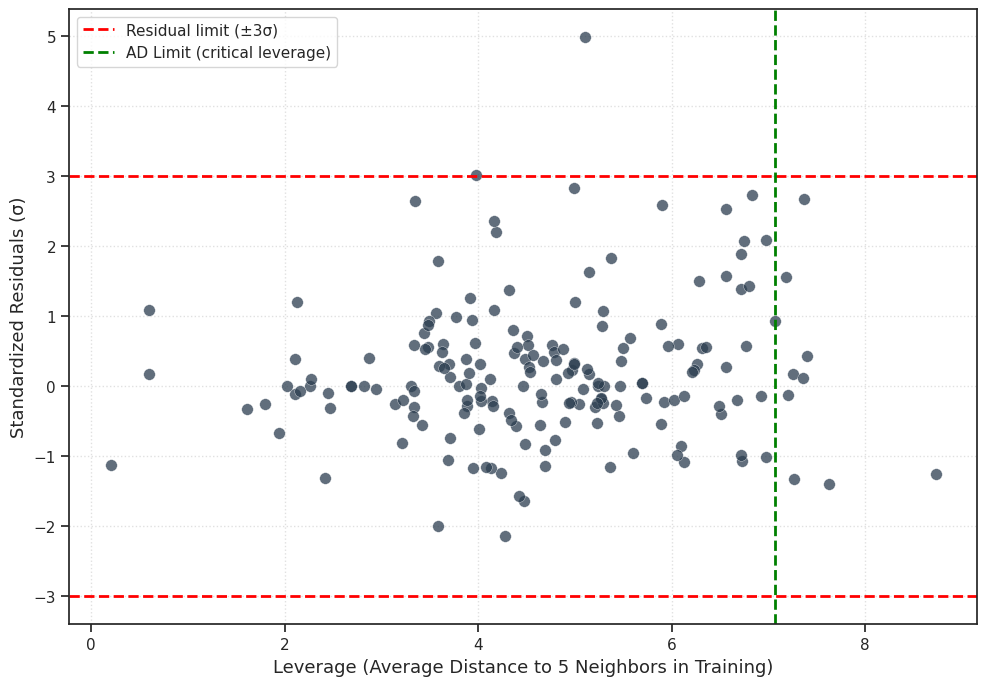

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


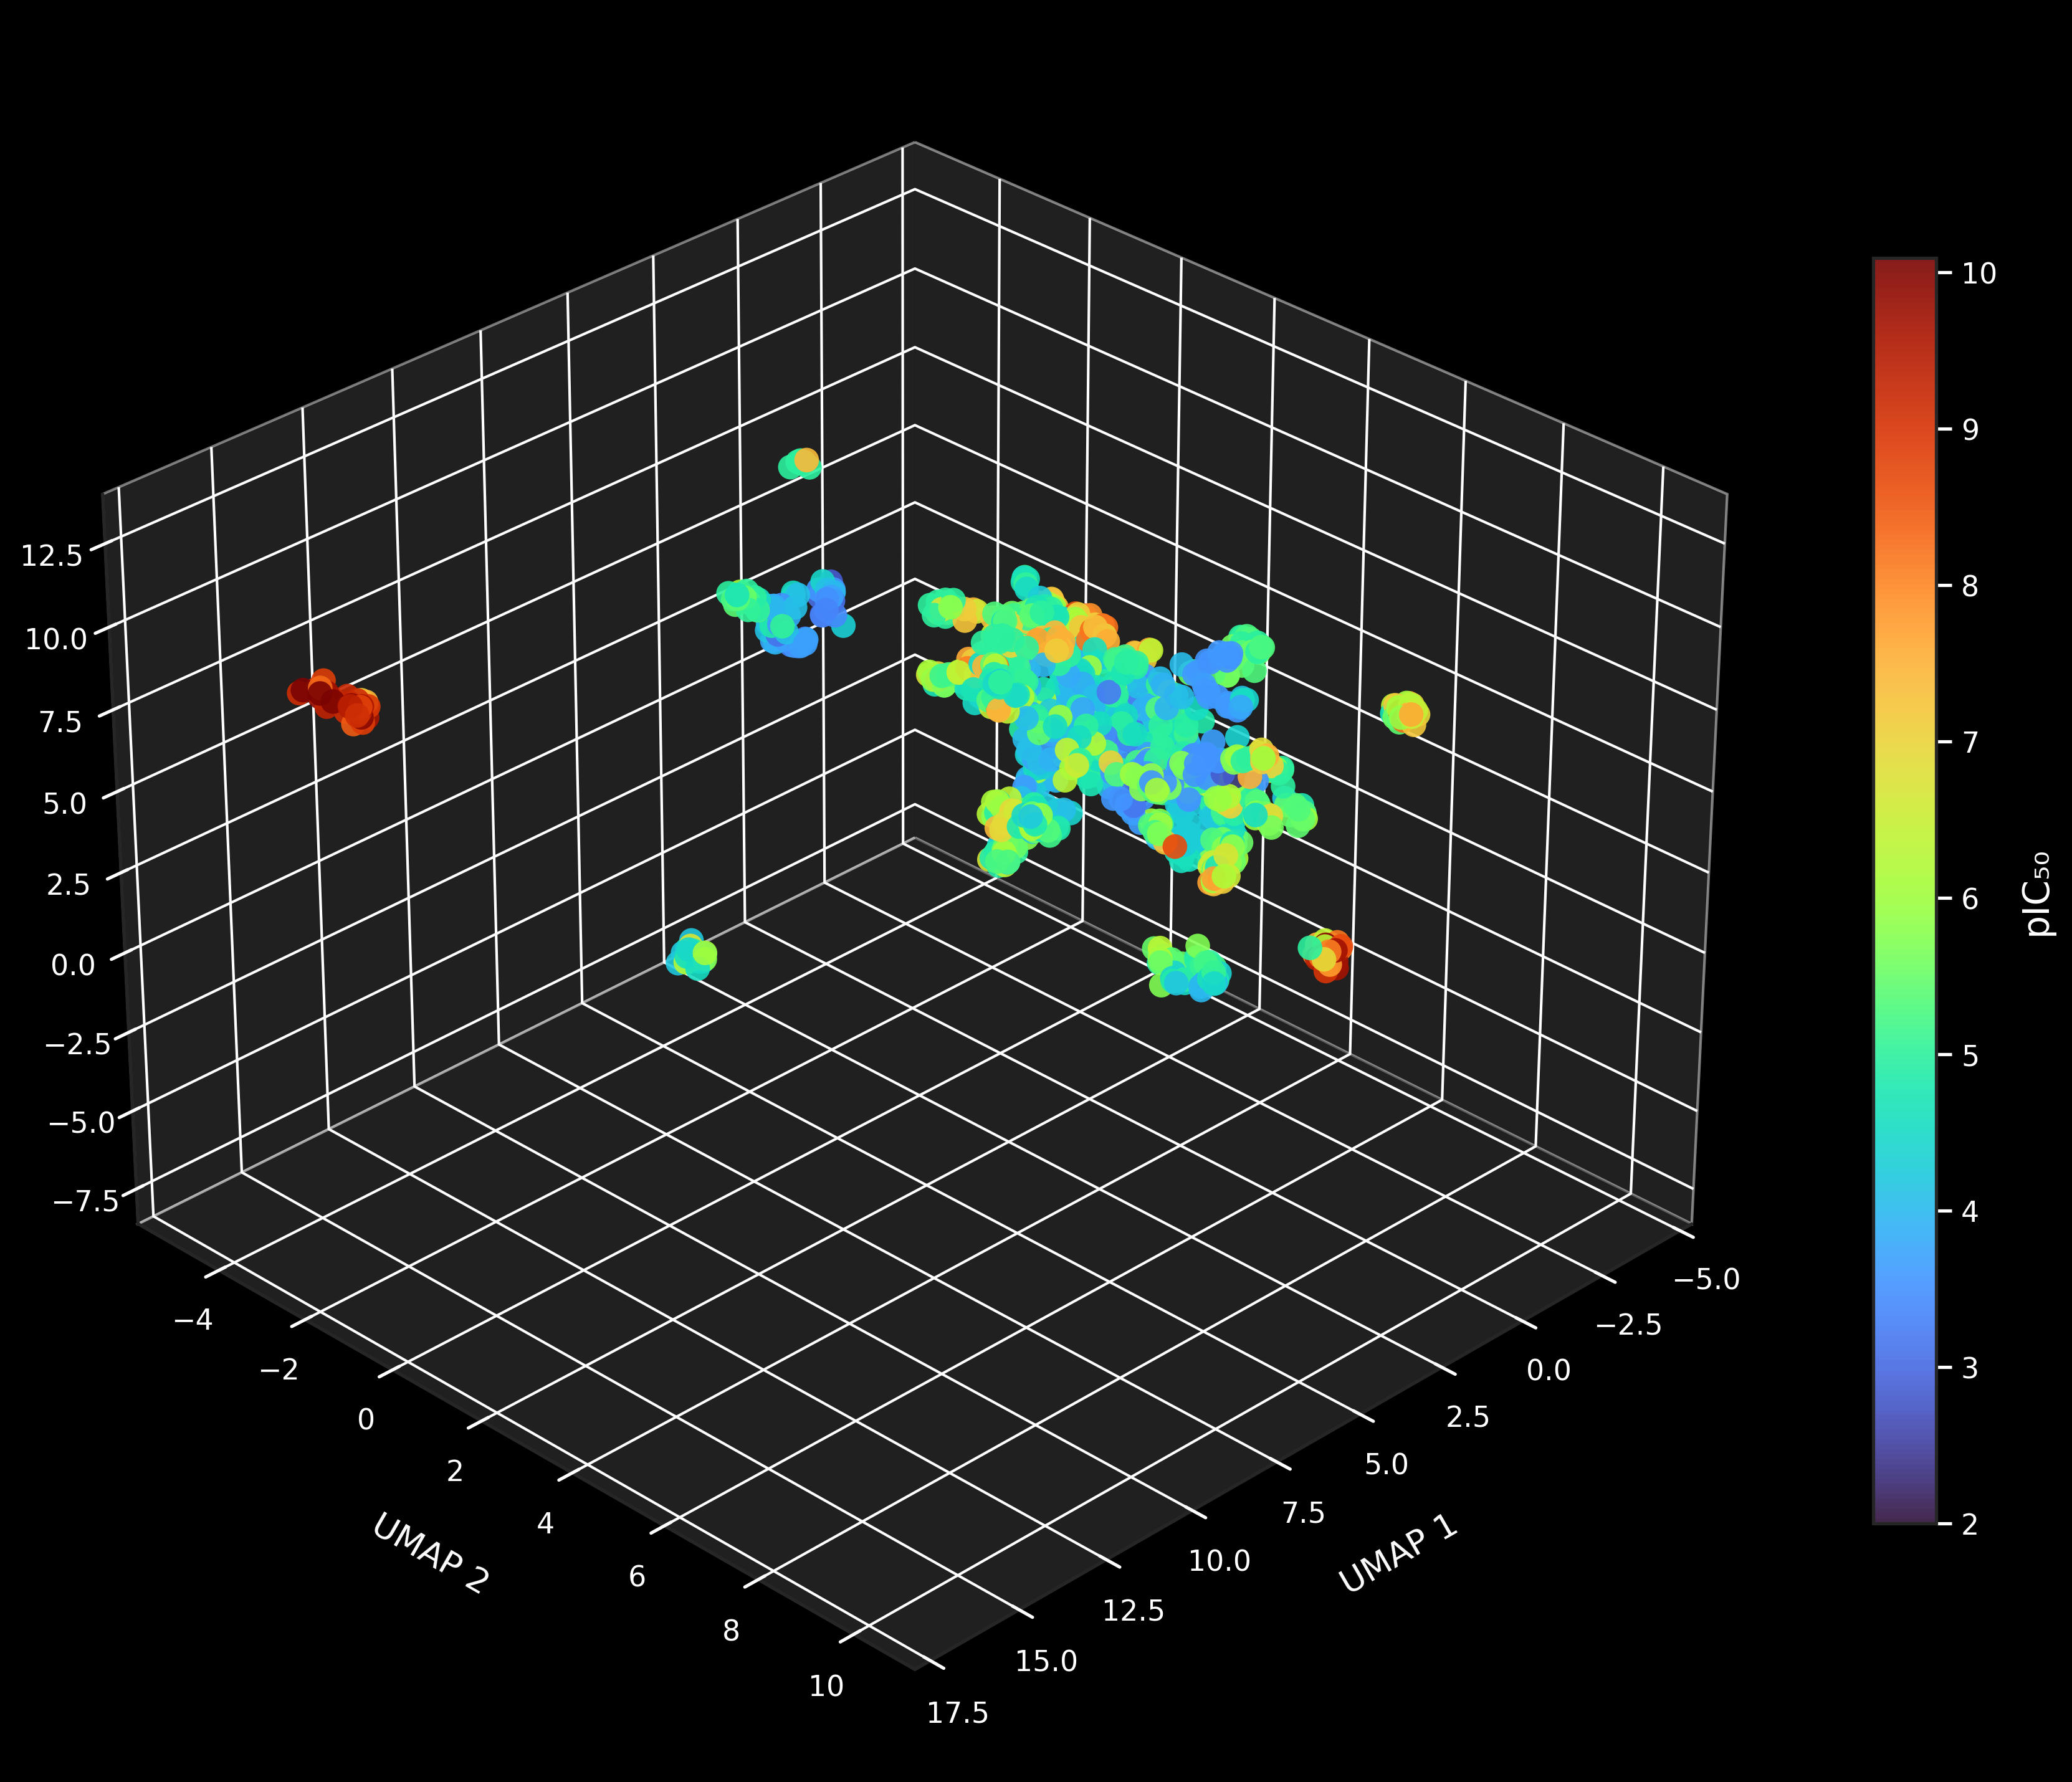

In [ ]:
# ==========================================================
# SECTION 2 - MACHINE LEARNING ANALYSIS
# ==========================================================


!pip install rdkit scikit-learn pandas numpy matplotlib seaborn umap-learn -q


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor, NearestNeighbors

sns.set_theme(style="ticks")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11


# Data loading and fingerprint generation
# Curated dataset available at: data/tcruzi_bioactivity_dataset.csv (generated by section 1, from ChEMBL v33)

df = pd.read_csv('data/tcruzi_bioactivity_dataset.csv')

def smiles_to_ecfp4(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    return np.array(morgan_gen.GetFingerprint(mol))

fps = df['canonical_smiles'].apply(smiles_to_ecfp4)
validos = fps.notna()

X_all      = np.vstack(fps[validos].values)
y_all      = df.loc[validos, 'pIC50'].values
smiles_all = df.loc[validos, 'canonical_smiles'].values



# Models train-test split
X_train, X_test, y_train, y_test, smiles_train, smiles_test = train_test_split(
    X_all, y_all, smiles_all,
    test_size=0.15,
    random_state=42
)

print(f"Training: {len(X_train)} compounds | Test: {len(X_test)} compounds")


# Model training and evaluation
modelos = {
    "Random Forest":     RandomForestRegressor(n_estimators=400, max_features='sqrt',
                                                random_state=42, n_jobs=-1),
    "Support Vector":    SVR(kernel='rbf', C=10.0, epsilon=0.1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                                    random_state=42),
    "K-Neighbors (KNN)": KNeighborsRegressor(n_neighbors=5, weights='distance')
}

metricas = {}
for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    preds = modelo.predict(X_test)
    metricas[nome] = {
        'R2':     r2_score(y_test, preds),
        'RMSE':   np.sqrt(mean_squared_error(y_test, preds)),
        'MAE':    mean_absolute_error(y_test, preds),
        'model': modelo
    }

print("\n" + "="*62)
print(f"{'Model':<22} | {'R² Training':<10} | {'RMSE':<8} ")
print("-"*62)
for nome, info in metricas.items():
    print(f"{nome:<22} | {info['R2']:<10.3f} | {info['RMSE']:<8.3f} ")
print("="*62)


# KNN Model
knn_model    = metricas["K-Neighbors (KNN)"]['model']

cv_r2   = cross_val_score(knn_model, X_all, y_all, cv=5, scoring='r2')
cv_rmse = cross_val_score(knn_model, X_all, y_all, cv=5,
                          scoring='neg_root_mean_squared_error')

print(f"\n KNN model:")
print(f"  R²   = {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
print(f"  RMSE = {(-cv_rmse).mean():.3f} ± {(-cv_rmse).std():.3f}")

y_pred_train = knn_model.predict(X_train)
y_pred_test  = knn_model.predict(X_test)



# External Validation — LCFD series compounds
# Experimental data obtained from internal biological assays

bench_data = {
    "LCF548":  {"smiles": r"OC(CN(C)CC1=CC=CC(C2=NOC(C3=CC=CC=C3)=N2)=C1)=O",                "ic50_uM": 36.54},
    "LCF553":  {"smiles": r"CN(CC(O)=O)CC1=CC=CC(C2=NOC(C)=N2)=C1",                           "ic50_uM": 28.09},
    "LCFD511": {"smiles": r"N/C(C1=CC(CN(CC(OCC)=O)C)=CC=C1)=N\O",                            "ic50_uM":  7.50},
    "LCFD509": {"smiles": r"O=C(OCC)CNCC1=CC=CC(C#N)=C1",                                     "ic50_uM": 11.10},
    "LCFD501": {"smiles": r"COCC1CC(CCC1N2CCCCC2)C(=O)O",                                     "ic50_uM": 28.25},
    "LCFD528": {"smiles": r"COCC1=CC(C2=NC(C3=CC(CN(C)CC(OCC)=O)=CC=C3)=NO2)=CC=C1N4CCCCC4", "ic50_uM":  8.20},
    "LCFD516": {"smiles": r"CN(CC(OCC)=O)CC1=CC=CC(C2=NOC(C)=N2)=C1",                        "ic50_uM": 12.50},
    "LCFD523": {"smiles": r"COCC1=CC(C2=NC(C3=CC=CC=C3)=NO2)=CC=C1N4CCCCC4",                 "ic50_uM": 23.88},
    "LCFD541": {"smiles": r"C/C=C\C(C1=NC(C2=CC(CN(C)CC(OCC)=O)=CC=C2)=NO1)=C",             "ic50_uM": 18.20},
}

compostos, pic50_exp, pic50_pred_knn = [], [], []

for nome, info in bench_data.items():
    fp = smiles_to_ecfp4(info["smiles"])
    if fp is not None:
        pic50_exp_val  = -np.log10(info["ic50_uM"] * 1e-6)
        pic50_pred_val = knn_model.predict([fp])[0]
        compostos.append(nome)
        pic50_exp.append(pic50_exp_val)
        pic50_pred_knn.append(pic50_pred_val)

df_bench = pd.DataFrame({
    'Compound':        compostos,
    'pIC50 Exp.':      pic50_exp,
    'pIC50 KNN':       pic50_pred_knn,

})

print("\n" + "="*58)
print("External Validation — pIC50 EXPERIMENTAL vs KNN")
print("="*58)
print(df_bench.to_string(index=False, float_format='{:.2f}'.format))



# Prediction for the suggested structural modifications of LCFD series derivatives
todos_compostos = {
    # Experimental series
    **{k: v["smiles"] for k, v in bench_data.items()},
    # Planned modifications — variations at R1 and R2 (H vs. methyl)
    'VAR1H':   r'N(CC1=CC=CC(C2=NOC(C)=N2)=C1)C[C@H](CS)C(=O)OCC',
    'VAR1MET': r'CN(CC1=CC=CC(C2=NOC(C)=N2)=C1)C[C@H](CS)C(=O)OCC',
    'VAR2H':   r'N(CC1=CC=CC(C2=NOC(C)=N2)=C1)C[C@H](CCSC)C(=O)OCC',
    'VAR2MET': r'CN(CC1=CC=CC(C2=NOC(C)=N2)=C1)C[C@H](CCSC)C(=O)OCC',
    'VAR3H':   r'N(CC1=CC=CC(C2=NOC(C)=N2)=C1)C[C@H](C)C(=O)OCC',
    'VAR3MET': r'CN(CC1=CC=CC(C2=NOC(C)=N2)=C1)C[C@H](C)C(=O)OCC',
    'VAR4H':   r'N(CC1=CC=CC(C2=NOC(C)=N2)=C1)C[C@H](C(C)C)C(=O)OCC',
    'VAR4MET': r'CN(CC1=CC=CC(C2=NOC(C)=N2)=C1)C[C@H](C(C)C)C(=O)OCC',
    'VAR5H':   r'N(CC1=CC=CC(C2=NOC(C)=N2)=C1)C[C@H](CC(C)C)C(=O)OCC',
    'VAR5MET': r'CN(CC1=CC=CC(C2=NOC(C)=N2)=C1)C[C@H](CC(C)C)C(=O)OCC',
    'VAR6H':   r'N(CC1=CC=CC(C2=NOC(C)=N2)=C1)CC(C(=O)OCC)',
    'VAR6MET': r'CN(CC1=CC=CC(C2=NOC(C)=N2)=C1)CC(C(=O)OCC)',
}

dados_pred = []
for nome_comp, smiles in todos_compostos.items():
    fp = smiles_to_ecfp4(smiles)
    if fp is not None:
        for nome_mod, info in metricas.items():
            pred = info['model'].predict([fp])[0]
            dados_pred.append({
                'Compound': nome_comp,
                'Model':   nome_mod,
                'pIC50':    round(pred, 2)
            })

df_pred  = pd.DataFrame(dados_pred)
df_pivot = df_pred.pivot(index='Compound', columns='Model', values='pIC50')

print("\n" + "="*58)
print("\n Model Predictions ")
print(df_pivot.to_string(float_format='{:.2f}'.format))
print("\n" + "="*58)

# Actual vs. Predicted Plot — KNN
fig, ax = plt.subplots(figsize=(7, 5.5))

sns.scatterplot(x=y_train, y=y_pred_train, ax=ax,
                alpha=0.7, color='green', edgecolor='none', label='Training')
sns.scatterplot(x=y_test,  y=y_pred_test,  ax=ax,
                alpha=0.9, color='#2980b9', edgecolor='none', label='Test')

plot_min, plot_max = 2.0, 10.5
ax.set_xlim(plot_min, plot_max)
ax.set_ylim(plot_min, plot_max)
ax.set_aspect('equal', adjustable='box')
ax.plot([plot_min, plot_max], [plot_min, plot_max],
        color='#c0392b', linestyle='--', lw=2, label='Ideal line (y=x)')

# Highlight the 4 largest outliers / activity cliffs
abs_errors  = np.abs(y_test - y_pred_test)
outlier_idx = np.argsort(abs_errors)[-4:]
ax.scatter(y_test[outlier_idx], y_pred_test[outlier_idx],
           color='red', marker='o', zorder=3, edgecolor='none', s=60)

ax.set_xlabel('pIC₅₀ Real (ChEMBL)')
ax.set_ylabel('pIC₅₀ Predict (KNN)')
ax.legend(loc='best')
plt.tight_layout()
plt.savefig('knn_performance.png', dpi=300, bbox_inches='tight')
plt.show()



# WILLIAMS PLOT — Domain of Applicability
residuals_std = (y_test - y_pred_test) / np.std(y_test - y_pred_test)

nn_model = NearestNeighbors(n_neighbors=knn_model.n_neighbors, metric='euclidean')
nn_model.fit(X_train)

leverage_test,  _ = nn_model.kneighbors(X_test)
leverage_test     = np.mean(leverage_test, axis=1)
leverage_train, _ = nn_model.kneighbors(X_train)
leverage_train    = np.mean(leverage_train, axis=1)

leverage_critical = np.mean(leverage_train) + 3 * np.std(leverage_train)

fig_w, ax_w = plt.subplots(figsize=(10, 7))
sns.scatterplot(x=leverage_test, y=residuals_std, ax=ax_w,
                alpha=0.75, color='#2c3e50', edgecolor='white', linewidth=0.3, s=70)

ax_w.axhline( 3, color='red',   linestyle='--', lw=2, label='Residual limit (±3σ)')
ax_w.axhline(-3, color='red',   linestyle='--', lw=2)
ax_w.axvline(leverage_critical, color='green', linestyle='--', lw=2,
             label='AD Limit (critical leverage)')

ax_w.set_xlabel(f'Leverage (Average Distance to {knn_model.n_neighbors} Neighbors in Training)', fontsize=13)
ax_w.set_ylabel('Standardized Residuals (σ)', fontsize=13)
ax_w.legend(fontsize=11, loc='upper left')
ax_w.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('williams_plot_knn.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()



# 3D UMAP — Chemical Space
umapper = umap.UMAP(n_components=3, random_state=42, n_neighbors=30, min_dist=0.5)
X_umap  = umapper.fit_transform(X_all)

df_umap = pd.DataFrame(X_umap, columns=['UMAP1', 'UMAP2', 'UMAP3'])
df_umap['pIC50'] = y_all

fig_umap = plt.figure(figsize=(12, 10), dpi=300)
ax_umap  = fig_umap.add_subplot(111, projection='3d')
fig_umap.patch.set_facecolor('black')
ax_umap.set_facecolor('black')

gray = (0.25, 0.25, 0.25, 0.6)
for pane in [ax_umap.xaxis.pane, ax_umap.yaxis.pane, ax_umap.zaxis.pane]:
    pane.set_facecolor(gray)
for axis in [ax_umap.xaxis, ax_umap.yaxis, ax_umap.zaxis]:
    axis._axinfo['grid']['color'] = 'white'
    axis._axinfo['grid']['alpha'] = 0.15
    axis._axinfo['axisline']['color'] = 'gray'

sc = ax_umap.scatter(df_umap['UMAP1'], df_umap['UMAP2'], df_umap['UMAP3'],
                     c=df_umap['pIC50'], cmap='turbo',
                     s=90, alpha=0.9, edgecolors='none')

ax_umap.set_xlabel('UMAP 1', color='white', labelpad=14, fontsize=13)
ax_umap.set_ylabel('UMAP 2', color='white', labelpad=14, fontsize=13)
ax_umap.set_zlabel('UMAP 3', color='white', labelpad=14, fontsize=13)
for axis in ['x', 'y', 'z']:
    ax_umap.tick_params(axis=axis, colors='white', labelsize=11)

cbar = fig_umap.colorbar(sc, ax=ax_umap, pad=0.05, shrink=0.7)
cbar.set_label('pIC₅₀', color='white', fontsize=14, labelpad=8)
cbar.ax.yaxis.set_tick_params(color='white', labelsize=11)
plt.setp(plt.getp(cbar.ax.yaxis, 'ticklabels'), color='white')

ax_umap.view_init(elev=30, azim=45)
plt.tight_layout()
plt.savefig('umap_3d_chemical_space.png', dpi=300, bbox_inches='tight', facecolor='black')
plt.show()